# **Ridge Regression Model**

**Team 3 | ECS 171 | Nidhi Deshmukh**

This notebook implements Ridge Regression to study the effect of regularization on house price prediction.

- Load the team's feature-selected dataset
- 75 / 25 train-test split
- 5-fold cross-validation for hyperparameter tuning
- Train a baseline Ridge model
- Evaluate performance using RMSE, MAE, and R²
- Tune the alpha (regularization) parameter
- Analyze regularization effects on coefficients

### **1. Imports**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 120

### **2. Load Dataset**

In [23]:
#Load the feature-selected dataset
df = pd.read_csv('/Users/nidhideshmukh/ECS171_Team3_Project/data/processed/housing_feature_selected.csv')

df.head()

,latitude,housing_median_age,median_income,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,median_house_value
0,37,41,8,0,1,0,6.984127,0.146591,452600.0
1,37,21,8,0,1,0,6.238137,0.155797,358500.0
2,37,52,7,0,1,0,8.288136,0.129516,352100.0
3,37,52,5,0,1,0,5.817352,0.184458,341300.0
4,37,52,3,0,1,0,6.281853,0.172096,342200.0


### **3. Train-Test Split**

In [22]:
#Separate features (X) and target (y)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

#75-25 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"# of features: {X_train.shape[1]}")

Training samples: 15480
Testing samples: 5160
# of features: 8


### **4. Feature Scaling**

Ridge regression is sensitive to feature scales because the regularization penalty is applied to all coefficients equally. StandardScaler transforms features to have mean=0 and standard deviation=1, ensuring fair regularization.

In [21]:
#standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **5. Baseline Ridge Model**

Train a Ridge regression model with default alpha=1.0 to establish a baseline.

In [20]:
#Train baseline Ridge model (alpha=1.0 by default)
ridge_baseline = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge_baseline.fit(X_train_scaled, y_train)

#Make predictions
y_train_pred = ridge_baseline.predict(X_train_scaled)
y_test_pred = ridge_baseline.predict(X_test_scaled)

#Evaluate
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("BASELINE RIDGE MODEL (alpha=1.0)")
print("="*50)
print(f"Training RMSE:   ${train_rmse:,.0f}")
print(f"Testing RMSE:    ${test_rmse:,.0f}")
print(f"Training MAE:    ${train_mae:,.0f}")
print(f"Testing MAE:     ${test_mae:,.0f}")
print(f"Training R²:     {train_r2:.4f}")
print(f"Testing R²:      {test_r2:.4f}")

BASELINE RIDGE MODEL (alpha=1.0)
Training RMSE:   $73,263
Testing RMSE:    $76,512
Training MAE:    $53,373
Testing MAE:     $54,639
Training R²:     0.5977
Testing R²:      0.5576


### **6. Hyperparameter Tuning with GridSearchCV**

Use 5-fold cross-validation to find the optimal alpha (regularization strength) parameter.

In [19]:
#Define parameter grid for alpha
#Alpha controls regularization strength: higher alpha = more regularization
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0]
}

#Setup GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=Ridge(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',  
    n_jobs=-1,
    verbose=1
)

#Fit grid search
grid_search.fit(X_train_scaled, y_train)

#Get best parameters
best_alpha = grid_search.best_params_['alpha']
best_cv_rmse = -grid_search.best_score_  

print("\n")
print("GRID SEARCH RESULTS")
print("="*50)
print(f"Best alpha:      {best_alpha}")
print(f"Best CV RMSE:    ${best_cv_rmse:,.0f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits


GRID SEARCH RESULTS
Best alpha:      10.0
Best CV RMSE:    $73,290


### **7. Train Final Model with Best Alpha**

In [17]:
#Train Ridge model with best alpha
best_ridge = Ridge(alpha=best_alpha, random_state=RANDOM_STATE)
best_ridge.fit(X_train_scaled, y_train)

#Make predictions
y_train_pred_best = best_ridge.predict(X_train_scaled)
y_test_pred_best = best_ridge.predict(X_test_scaled)

#Evaluate
train_rmse_best = np.sqrt(mean_squared_error(y_train, y_train_pred_best))
test_rmse_best = np.sqrt(mean_squared_error(y_test, y_test_pred_best))
train_mae_best = mean_absolute_error(y_train, y_train_pred_best)
test_mae_best = mean_absolute_error(y_test, y_test_pred_best)
train_r2_best = r2_score(y_train, y_train_pred_best)
test_r2_best = r2_score(y_test, y_test_pred_best)

print(f"TUNED RIDGE MODEL (alpha={best_alpha})")
print("="*50)
print(f"Training RMSE:   ${train_rmse_best:,.0f}")
print(f"Testing RMSE:    ${test_rmse_best:,.0f}")
print(f"Training MAE:    ${train_mae_best:,.0f}")
print(f"Testing MAE:     ${test_mae_best:,.0f}")
print(f"Training R²:     {train_r2_best:.4f}")
print(f"Testing R²:      {test_r2_best:.4f}")


TUNED RIDGE MODEL (alpha=10.0)
Training RMSE:   $73,263
Testing RMSE:    $76,491
Training MAE:    $53,376
Testing MAE:     $54,634
Training R²:     0.5977
Testing R²:      0.5578


### **8. Predicted vs Actual Plot**

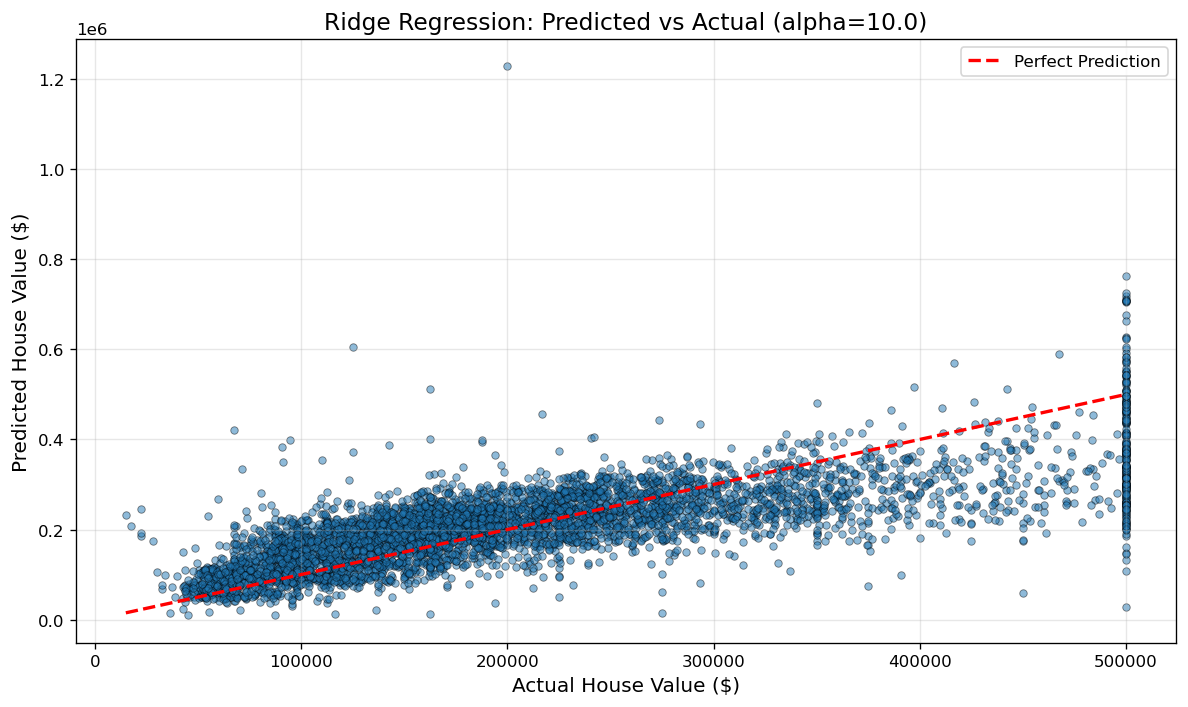

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred_best, alpha=0.5, s=20, edgecolors='k', linewidths=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual House Value ($)', fontsize=12)
plt.ylabel('Predicted House Value ($)', fontsize=12)
plt.title(f'Ridge Regression: Predicted vs Actual (alpha={best_alpha})', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **9. Residual Plot**

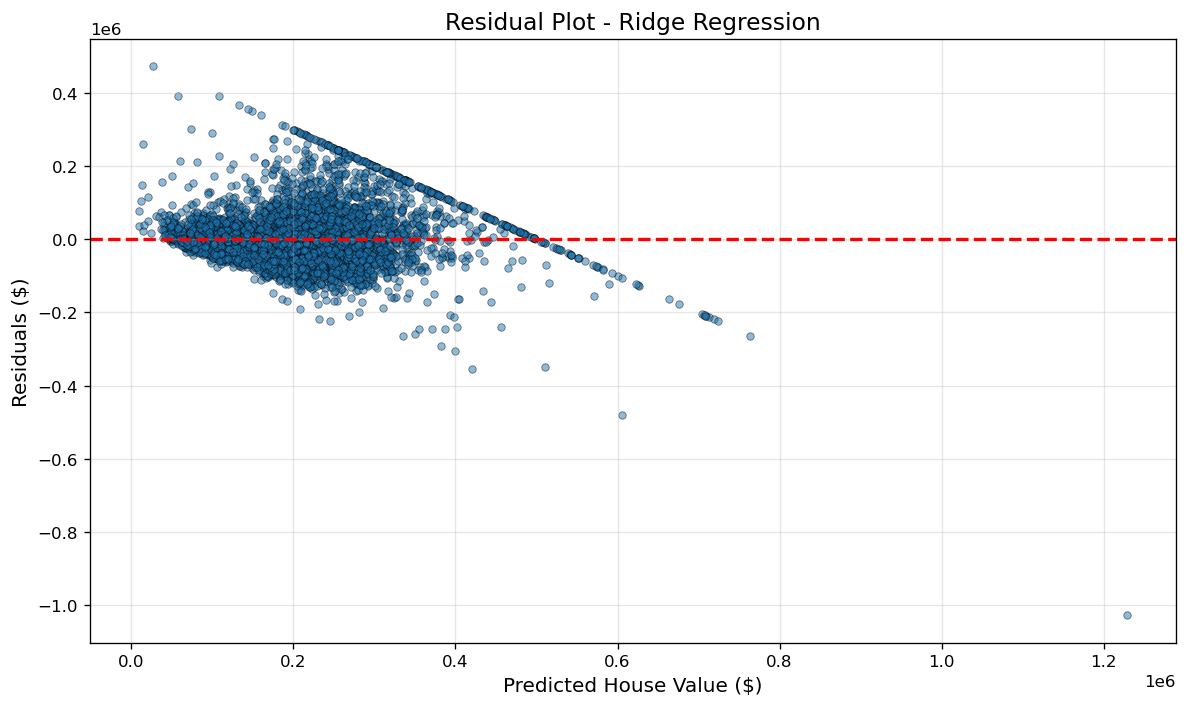

In [11]:
residuals = y_test - y_test_pred_best

plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred_best, residuals, alpha=0.5, s=20, edgecolors='k', linewidths=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted House Value ($)', fontsize=12)
plt.ylabel('Residuals ($)', fontsize=12)
plt.title('Residual Plot - Ridge Regression', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **10. Effect of Alpha on Model Performance**

Visualize how different alpha values affect cross-validation RMSE to understand the regularization effect.

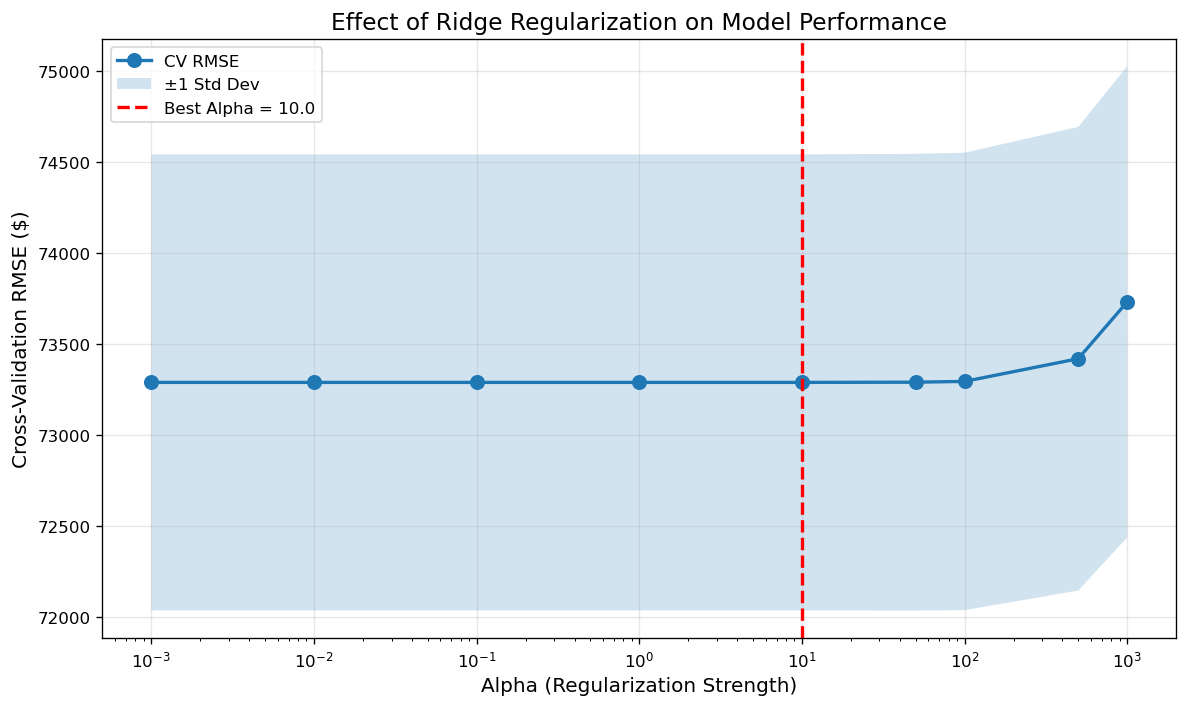

In [12]:
#CV results
cv_results = pd.DataFrame(grid_search.cv_results_)
alphas = cv_results['param_alpha'].values
mean_test_rmse = -cv_results['mean_test_score'].values  # Convert to positive RMSE
std_test_rmse = cv_results['std_test_score'].values

#Plot alpha vs RMSE
plt.figure(figsize=(10, 6))
plt.semilogx(alphas, mean_test_rmse, marker='o', linewidth=2, markersize=8, label='CV RMSE')
plt.fill_between(alphas, 
                 mean_test_rmse - std_test_rmse,
                 mean_test_rmse + std_test_rmse,
                 alpha=0.2, label='±1 Std Dev')
plt.axvline(x=best_alpha, color='r', linestyle='--', linewidth=2, label=f'Best Alpha = {best_alpha}')
plt.xlabel('Alpha (Regularization Strength)', fontsize=12)
plt.ylabel('Cross-Validation RMSE ($)', fontsize=12)
plt.title('Effect of Ridge Regularization on Model Performance', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **11. Coefficient Analysis**

Compare coefficients between baseline (alpha=1.0) and tuned model to see regularization effects.

In [16]:
#Create coefficient comparison DataFrame
coef_comparison = pd.DataFrame({
    'Feature': X.columns,
    'Baseline (alpha=1.0)': ridge_baseline.coef_,
    f'Tuned (alpha={best_alpha})': best_ridge.coef_
})

#Sort by absolute value of tuned coefficients
coef_comparison['Abs_Tuned'] = np.abs(coef_comparison[f'Tuned (alpha={best_alpha})'])
coef_comparison = coef_comparison.sort_values('Abs_Tuned', ascending=False).drop('Abs_Tuned', axis=1)

print("COEFFICIENT COMPARISON (sorted by importance)")
print(coef_comparison.to_string(index=False))

COEFFICIENT COMPARISON (sorted by importance)
                   Feature  Baseline (alpha=1.0)  Tuned (alpha=10.0)
             median_income          80730.544254        80639.714138
    ocean_proximity_INLAND         -32395.836203       -32398.855440
         bedrooms_per_room          17100.047831        17033.889493
        housing_median_age          11605.445225        11592.963996
       rooms_per_household           5845.283284         5844.122812
ocean_proximity_NEAR OCEAN           5623.372281         5622.909268
                  latitude           3677.727677         3658.523551
  ocean_proximity_NEAR BAY           2872.919189         2884.934838


### **12. Visualize Coefficient Magnitudes**

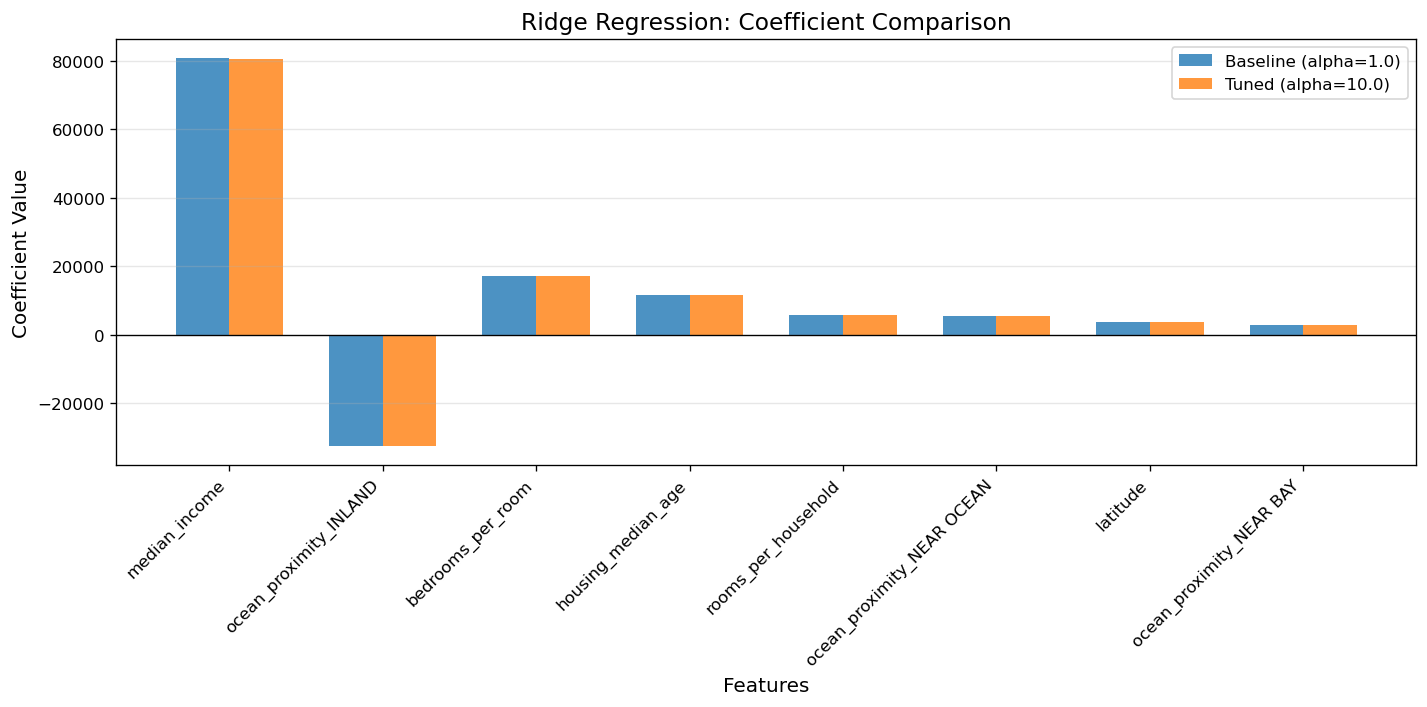

In [14]:
#Prepare data for plotting
features = coef_comparison['Feature'].values
baseline_coefs = coef_comparison['Baseline (alpha=1.0)'].values
tuned_coefs = coef_comparison[f'Tuned (alpha={best_alpha})'].values

x = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, baseline_coefs, width, label='Baseline (alpha=1.0)', alpha=0.8)
bars2 = ax.bar(x + width/2, tuned_coefs, width, label=f'Tuned (alpha={best_alpha})', alpha=0.8)

ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Coefficient Value', fontsize=12)
ax.set_title('Ridge Regression: Coefficient Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha='right')
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### **13. Regularization Path Visualization**

Show how coefficients shrink as alpha increases.

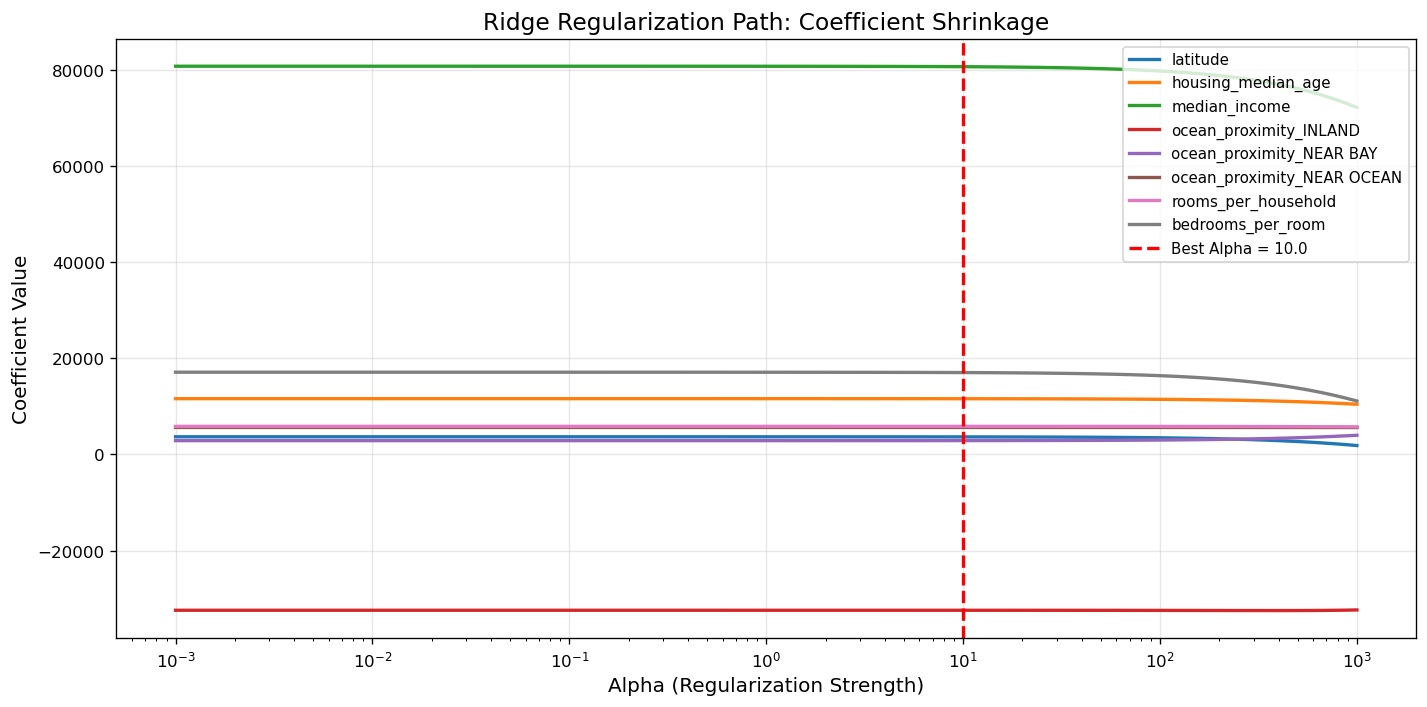

In [15]:
#Train Ridge models with different alphas to visualize coefficient paths
alphas_path = np.logspace(-3, 3, 100)  #100 alpha values from 0.001 to 1000
coefs_path = []

for alpha in alphas_path:
    ridge = Ridge(alpha=alpha, random_state=RANDOM_STATE)
    ridge.fit(X_train_scaled, y_train)
    coefs_path.append(ridge.coef_)

coefs_path = np.array(coefs_path)

#Plot regularization path
plt.figure(figsize=(12, 6))
for i, feature in enumerate(X.columns):
    plt.plot(alphas_path, coefs_path[:, i], label=feature, linewidth=2)

plt.axvline(x=best_alpha, color='red', linestyle='--', linewidth=2, label=f'Best Alpha = {best_alpha}')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.title('Ridge Regularization Path: Coefficient Shrinkage', fontsize=14)
plt.legend(loc='best', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **14. Model Interpretation**

#### **Performance Summary**

The Ridge regression model achieved:

Best alpha: 10.0 (from 5-fold cross-validation)
Test RMSE: $76,491
Test R²: 0.5578 (explains 55.8% of house price variance)

The minimal improvement from baseline (alpha=1.0) to tuned (alpha=10.0) shows that regularization had little effect because the preprocessed features already have low multicollinearity.

#### **Feature Importance**
Top 3 most important features based on coefficients:

median_income (+$80,640): Strongest predictor - each standard deviation increase in income raises house value by ~$80,640
ocean_proximity_INLAND (-$32,399): Inland properties worth $32,400 less than coastal areas
bedrooms_per_room (+$17,034): Higher bedroom density correlates with higher prices

#### **Effect of Regularization**
Comparing alpha=1.0 vs alpha=10.0 showed negligible coefficient changes (<1%), confirming that:

Features are already well-selected with low correlation
Ridge's L2 penalty provides minimal shrinkage
The feature set itself, not regularization strength, limits model performance

The regularization path shows all coefficients shrink smoothly as alpha increases, but none are eliminated (unlike Lasso).

#### **Key Findings**
Advantages: Handles multicollinearity, prevents overfitting, keeps all features, computationally efficient
Limitations: Cannot capture nonlinear relationships, moderate R² (44.2% variance unexplained), high RMSE ($76,500 average error), no automatic feature selection
Comparison to team models: Ridge performs similarly to Linear Regression and Lasso (~55-56% R²), but ensemble methods (Random Forest, Gradient Boosting) should outperform by capturing nonlinear patterns.